# Object Detection For Autonomous Driving

## Objective

The goal of this assignment is to fine-tune the YOLO object detection model on a subset of the KITTI dataset, widely used in autonomous driving research. The KITTI dataset provides annotated images for tasks like object detection, tracking, and segmentation, making it ideal for training models to detect objects such as cars, pedestrians, and cyclists.

By completing this assignment, you will gain hands-on experience in dataset preparation, annotation conversion, model training, and performance evaluation using metrics like mAP (mean Average Precision). Additionally, you will explore the trade-offs between speed and accuracy, crucial for real-time applications like autonomous driving.


## Introduction: Object Detection

Object detection is a fundamental task in computer vision that involves identifying and localizing objects within an image or video. 

The main techniques for object detection include traditional methods like sliding window and region-based approaches, as well as modern deep learning-based methods such as YOLO (You Only Look Once), SSD (Single Shot MultiBox Detector), and Faster R-CNN. These techniques leverage convolutional neural networks (CNNs) to extract features and predict bounding boxes and class labels for objects in real-time or near real-time. 

Widely used models for object detection include:
- **YOLO (You Only Look Once)**: Known for its speed and efficiency in real-time applications.
- **Faster R-CNN**: A two-stage detector that provides high accuracy but is slower compared to single-stage detectors.
- **SSD (Single Shot MultiBox Detector)**: Balances speed and accuracy, making it suitable for various applications.
- **RetinaNet**: Introduces the focal loss to address class imbalance in object detection.
- **EfficientDet**: A family of models that optimize both accuracy and efficiency using compound scaling.

In the context of autonomous vehicles, object detection plays a critical role in perceiving the environment, identifying obstacles, pedestrians, traffic signs, and other vehicles. This capability enables autonomous systems to make informed decisions, ensuring safety and efficiency in navigation and driving scenarios.

## YOLO

YOLO (You Only Look Once) is a state-of-the-art, real-time object detection system. Unlike traditional object detection methods that apply a classifier to different regions of an image, YOLO frames object detection as a single regression problem. It predicts bounding boxes and class probabilities directly from full images in one evaluation, making it extremely fast and efficient.

### Model

The YOLO model divides the input image into a grid, where each grid cell is responsible for predicting bounding boxes and their associated class probabilities. Key features of YOLO include:

- **Unified Architecture**: YOLO uses a single convolutional neural network (CNN) to predict multiple bounding boxes and class probabilities simultaneously.
- **Speed**: YOLO is optimized for real-time applications, capable of processing images at high frame rates.
- **Global Context**: By considering the entire image during training and inference, YOLO reduces false positives and improves detection accuracy.
- **Versions**: Over time, YOLO has evolved through multiple versions (e.g., YOLOv1 up to YOLOv11), each introducing architectural improvements, better loss functions, and enhanced performance.

YOLO is widely used in applications such as autonomous driving, surveillance, and robotics, where real-time object detection is critical.

For more details on YOLO, visit the [Ultralytics GitHub repository](https://github.com/ultralytics/ultralytics).

## Theory Questions


For the next questions, focus on the latest version of the model, YOLOv11

Briefly describe the architecture used in YOLOv11 and the different losses used during training.

ANS:

YOLOv11 is a single-stage, anchor-free object detector following the YOLO backbone-neck-head paradigm.

#### Backbone

The backbone is purely convolutional, built from CBS blocks (Convolution + Batch Normalisation + SiLU). The core unit is the C3k2 block, a Cross Stage Partial (CSP) bottleneck that splits the feature map channel-wise: one branch processes through bottleneck layers, the other bypasses as a residual shortcut, reducing gradient duplication. SPPF then captures multi-scale context by applying a small max-pool sequentially, exploiting the equivalence between stacked small kernels and a single large one. Finally, a C2PSA block applies spatial self-attention via scaled dot-product softmax, selectively amplifying relevant spatial regions before passing features to the neck.

#### Neck

The neck fuses multi-scale features via upsampling and concatenation of shallow and deep feature maps, using C3k2 and C2PSA blocks to refine representations across scales.

#### Head

The head is anchor-free and decoupled: it directly regresses the ltrb distances from each grid point to box boundaries, with separate branches for regression and classification.

#### Loss Functions

Training minimises a weighted sum $\mathcal{L} = \lambda_{\text{box}} \mathcal{L}_{\text{CIoU}} + \lambda_{\text{cls}} \mathcal{L}_{\text{WBCE}} + \lambda_{\text{dfl}} \mathcal{L}_{\text{DFL}}$.

CIoU jointly penalises overlap, centre distance, and aspect ratio between predicted and ground-truth boxes, providing informative gradients even when boxes do not overlap.

WBCE applies per-class weights inversely proportional to class frequency, amplifying the gradient contribution of under-represented categories to correct class imbalance.

DFL reformulates coordinate regression as classification over a discrete distribution. The predicted coordinate is the expected value of that distribution, and the loss is cross-entropy against a soft label on the two nearest bins to the true coordinate. This naturally captures boundary ambiguity and produces sharper localisation as training progresses.

What are the metrics used to assess YOLO's performance for object detection?

ANS:

#### Precision and Recall

Precision measures what fraction of detections are correct; Recall measures what fraction of ground-truth objects were found. A detection is correct if its IoU with the ground truth exceeds a threshold.

#### IoU (Intersection over Union)

Ratio of the intersection area to the union area between a predicted and ground-truth box. It is the core matching criterion underpinning all higher-level metrics.

#### Average Precision (AP)

Area under the precision-recall curve for a single class, capturing performance across all confidence thresholds rather than at a single operating point.

#### mAP (mean Average Precision)

AP averaged across all classes. Two variants are standard: mAP@0.5 uses a fixed IoU threshold of 0.5, while mAP@0.5:0.95 averages over thresholds from 0.5 to 0.95 in steps of 0.05, penalising poor localisation more heavily. The latter is the primary COCO benchmark metric.

#### FPS / Latency

Throughput and latency are reported alongside accuracy, as YOLO targets real-time inference. The accuracy-speed trade-off is central to comparing YOLO variants.

## Code

In the next part of the assignment, you will load a YOLO model and fine-tune it on the provided subset of the KITTI dataset.
You will then visualize the training losses and evaluate the model by running inference to assess its performance.

In [1]:
!pip install ultralytics opencv-python-headless -q

In [2]:
import os, cv2, glob, random, shutil, requests, zipfile
from ultralytics import YOLO

import matplotlib.pyplot as plt
import pandas as pd
import os

%matplotlib inline

from IPython.display import Image, display
import glob

import yaml
import cv2
import matplotlib.pyplot as plt
import glob

In [3]:
# ---------------------------------------------
# STEP 1: Setup paths
# ---------------------------------------------
HOME = os.getcwd()
DATASET_PATH = os.path.join(HOME, "datasets", "kitti_subset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")

TRAIN_IMG = os.path.join(IMAGES_PATH, "train")
VAL_IMG = os.path.join(IMAGES_PATH, "val")
TEST_IMG = os.path.join(IMAGES_PATH, "test")
TRAIN_LABEL = os.path.join(LABELS_PATH, "train")
VAL_LABEL = os.path.join(LABELS_PATH, "val")
TEST_LABEL = os.path.join(LABELS_PATH, "test")


In [ ]:

for path in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_LABEL, VAL_LABEL, TEST_LABEL]:
    os.makedirs(path, exist_ok=True)

# ---------------------------------------------
# STEP 2: Download and extract KITTI data
# ---------------------------------------------
KITTI_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip"
KITTI_LABELS_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip"

def download_and_extract(url, extract_to):
    zip_path = os.path.join(HOME, url.split("/")[-1])
    if not os.path.exists(zip_path):
        print(f"Downloading {url}...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file.write(chunk)
        print("Download complete.")

    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

download_and_extract(KITTI_URL, IMAGES_PATH)
download_and_extract(KITTI_LABELS_URL, LABELS_PATH)

# ---------------------------------------------
# STEP 3: Convert KITTI annotations to YOLO
# ---------------------------------------------
CLASS_MAP = {"Car": 0, "Pedestrian": 1, "Cyclist": 2}

def convert_kitti_to_yolo(kitti_label_path, yolo_label_path, image_path):
    with open(kitti_label_path, "r") as file:
        lines = file.readlines()

    img = cv2.imread(image_path)
    if img is None:
        return
    height, width, _ = img.shape

    with open(yolo_label_path, "w") as yolo_file:
        for line in lines:
            elements = line.split()
            class_name = elements[0]
            if class_name not in CLASS_MAP:
                continue

            class_id = CLASS_MAP[class_name]
            x1, y1, x2, y2 = map(float, elements[4:8])

            # Convert to YOLO format
            center_x = ((x1 + x2) / 2) / width
            center_y = ((y1 + y2) / 2) / height
            bbox_width = (x2 - x1) / width
            bbox_height = (y2 - y1) / height

            yolo_file.write(f"{class_id} {center_x:.6f} {center_y:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

# ---------------------------------------------
# STEP 4: Prepare dataset (subset, split, convert)
# ---------------------------------------------
all_images = sorted(glob.glob(os.path.join(IMAGES_PATH, "training", "image_2", "*.png")))
all_labels = sorted(glob.glob(os.path.join(LABELS_PATH, "training", "label_2", "*.txt")))

paired_data = list(zip(all_images, all_labels))
random.seed(42)
random.shuffle(paired_data)

# Keep small subset (e.g., 300 images total)
subset_data = paired_data[:300]
train_size = int(0.8 * len(subset_data))
val_size = int(0.1 * len(subset_data))

train_data = subset_data[:train_size]
val_data = subset_data[train_size:train_size + val_size]
test_data = subset_data[train_size + val_size:]

def move_and_convert_files(data, img_dest, lbl_dest):
    for img_path, lbl_path in data:
        new_img_path = os.path.join(img_dest, os.path.basename(img_path))
        new_lbl_path = os.path.join(lbl_dest, os.path.basename(lbl_path))
        shutil.copy2(img_path, new_img_path)
        convert_kitti_to_yolo(lbl_path, new_lbl_path, new_img_path)

move_and_convert_files(train_data, TRAIN_IMG, TRAIN_LABEL)
move_and_convert_files(val_data, VAL_IMG, VAL_LABEL)
move_and_convert_files(test_data, TEST_IMG, TEST_LABEL)


# ---------------------------------------------
# STEP 5: Create data.yaml
# ---------------------------------------------
data_yaml = f"""
path: {DATASET_PATH}
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']
"""

with open(os.path.join(DATASET_PATH, "data.yaml"), "w") as f:
    f.write(data_yaml)


In [5]:
# ---------------------------------------------
# STEP 6: Fine-tune YOLOv11 model
# ---------------------------------------------
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

model = YOLO("yolo11n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=640,
    batch=16,
    lr0=1e-3,
    weight_decay=5e-4,
    optimizer="AdamW",
    patience=10,
    plots=True,
    project=os.path.join(HOME, "runs", "kitti_finetune"),
    name="yolo11n_kitti",
    exist_ok=True,
)

TRAIN_RUN_DIR = results.save_dir
print(f"Training complete")

Ultralytics 8.4.37 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (AMD Ryzen 7 7840U with Radeon 780M Graphics)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/markusdj/Documents/courses/dlfav/DLAV-2026/graded_homework/hw2/datasets/kitti_subset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_kit

# Inference

After training, visualize the losses andmetrics calculated on the validation set during training.

Additionally, make sure you visualize the confusion matrix to see per-class errors.

For qualitative analysis, run inference on the model, visualise the bouding boxes and visually assess it.

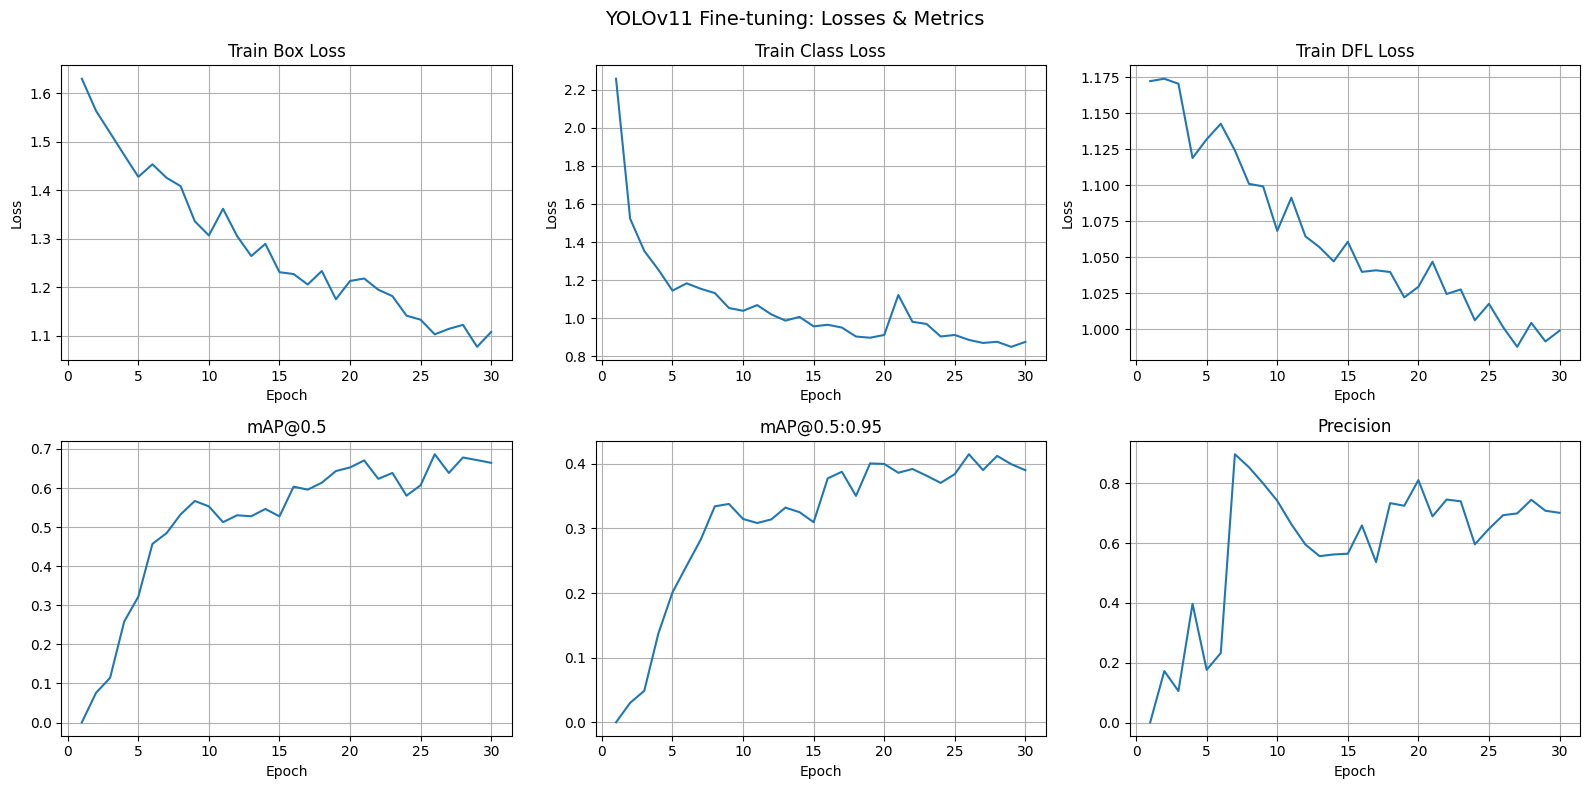

In [6]:
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------
results_csv = os.path.join(TRAIN_RUN_DIR, "results.csv")
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("YOLOv11 Fine-tuning: Losses & Metrics", fontsize=14)

loss_cols = [
    ("train/box_loss", "Train Box Loss"),
    ("train/cls_loss", "Train Class Loss"),
    ("train/dfl_loss", "Train DFL Loss"),
]
metric_cols = [
    ("metrics/mAP50(B)", "mAP@0.5"),
    ("metrics/mAP50-95(B)", "mAP@0.5:0.95"),
    ("metrics/precision(B)", "Precision"),
]

for ax, (col, title) in zip(axes[0], loss_cols):
    ax.plot(df["epoch"], df[col])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)

for ax, (col, title) in zip(axes[1], metric_cols):
    ax.plot(df["epoch"], df[col])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True)

plt.tight_layout()
plt.show()

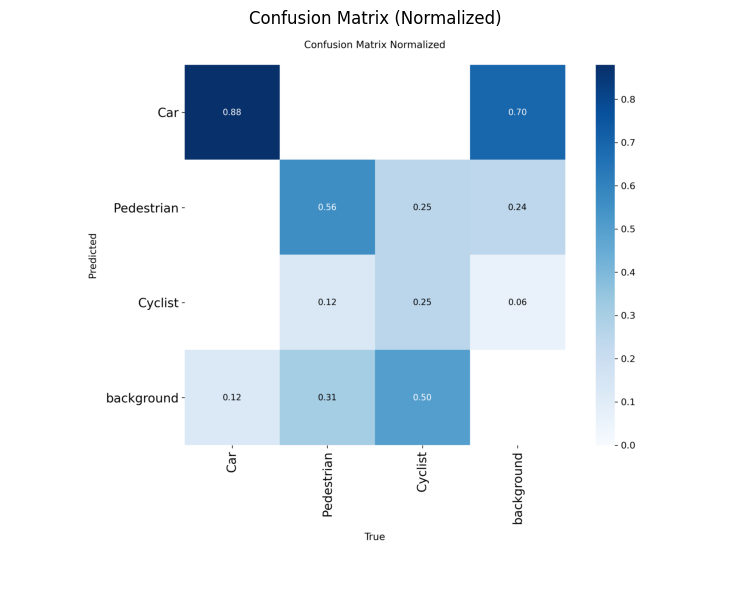

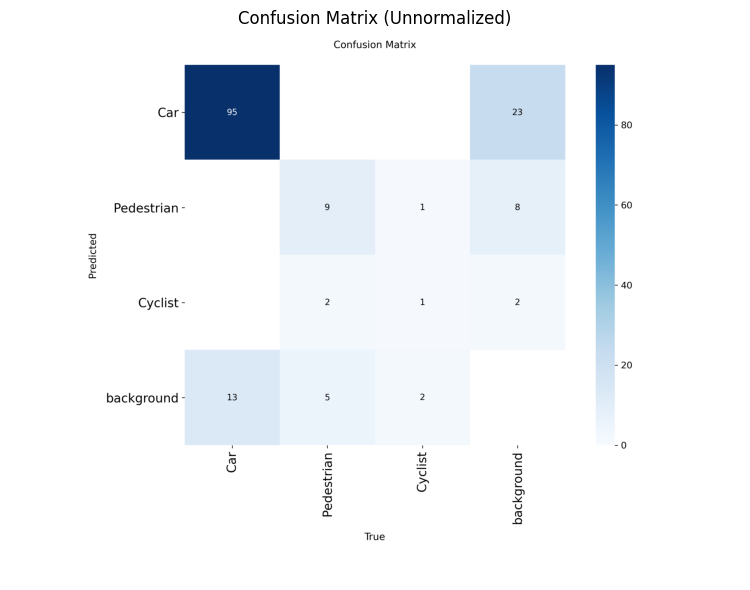

In [ ]:
# ------ VISUALIZE CONFUSION MATRIX --------
cm_path = os.path.join(TRAIN_RUN_DIR, "confusion_matrix_normalized.png")
if not os.path.exists(cm_path):
    cm_path = os.path.join(TRAIN_RUN_DIR, "confusion_matrix.png")

img = cv2.imread(cm_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Confusion Matrix (Normalized)")
plt.tight_layout()
plt.show()

cm_path = os.path.join(TRAIN_RUN_DIR, "confusion_matrix.png")
if os.path.exists(cm_path):
    img = cv2.imread(cm_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Confusion Matrix (Unnormalized)")
    plt.tight_layout()
    plt.show()

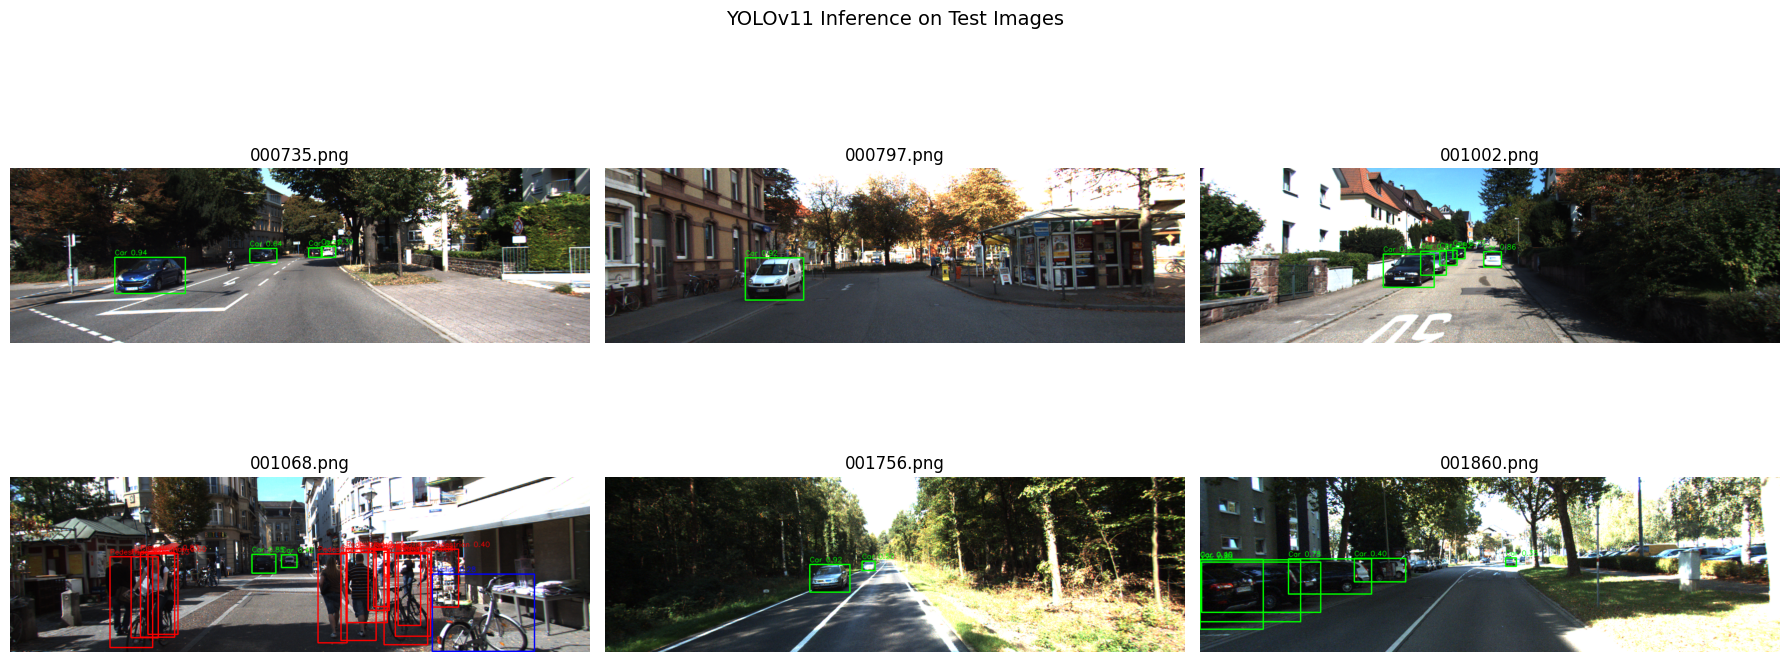

In [8]:
# -------- RUN INFERENCE AND PLOT SAMPLE OUTPUTS --------
best_weights = os.path.join(TRAIN_RUN_DIR, "weights", "best.pt")
inference_model = YOLO(best_weights)

test_images = sorted(glob.glob(os.path.join(TEST_IMG, "*.png")))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("YOLOv11 Inference on Test Images", fontsize=14)

CLASS_COLORS = {0: (0, 255, 0), 1: (255, 0, 0), 2: (0, 0, 255)}
CLASS_NAMES = {0: "Car", 1: "Pedestrian", 2: "Cyclist"}

for ax, img_path in zip(axes.flat, test_images):
    preds = inference_model(img_path, verbose=False)[0]
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        color = CLASS_COLORS.get(cls_id, (255, 255, 0))
        label = f"{CLASS_NAMES.get(cls_id, cls_id)} {conf:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, max(y1 - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path))

plt.tight_layout()
plt.show()

## Question

Comment on the performance of the model based on the visualizations you made and discuss the inference speed versus performance for YOLO on the driving datasets. Do you think we can use YOLO online on autonomous cars? 

## Ans

### Model Performance

All three losses (Box, Class, DFL) decrease steadily over 30 epochs with no divergence, indicating stable fine-tuning. The class loss drops most sharply in the first 5 epochs, suggesting the pretrained backbone already captures useful features and the head adapts quickly. mAP@0.5 reaches around 0.67 and mAP@0.5:0.95 around 0.40, reasonable for a small driving dataset. Precision is notably noisy, oscillating between 0.4 and 0.85, suggesting the model would benefit from more training data or threshold tuning.

Cars are detected well (95 true positives) but pedestrians and cyclists perform considerably worse, with only 9 and 1 true positives respectively and notable confusion against background. This reflects the class imbalance typical of driving datasets, where cars dominate, directly motivating the use of WBCE loss. In the inference images, cars are consistently detected with high confidence (0.7-0.94), while pedestrians and cyclists appear with lower confidence and some false positives in crowded scenes. Distant and small objects are largely missed, consistent with the lower mAP@0.5:0.95 score.

### Inference Speed

The model runs at 10.8ms per image, corresponding to roughly 93 FPS, well above the 30 FPS threshold considered necessary for real-time perception. Preprocessing and postprocessing add only 0.7ms combined, making the full pipeline approximately 11.5ms per frame. This speed profile is well suited to real-time applications and leaves headroom for parallel processing tasks.

### Suitability for Online Autonomous Driving

Whether YOLO can be used online in autonomous cars is nuanced. The speed is promising, but several concerns remain:

- Missing a pedestrian at 50km/h is a safety-critical failure that no amount of speed compensates for, and the current recall on vulnerable road users is too low for safe deployment.
- Autonomous systems typically run multiple perception models in parallel (depth estimation, lane detection, tracking), so the 11ms budget must be shared across tasks.
- YOLO produces no uncertainty estimates, whereas safety-critical systems generally require calibrated confidence to trigger fallback behaviours.

YOLO could realistically serve as one component in a multi-model perception stack, but not as a standalone detector without significantly improved recall on minority classes.